# 1_Limpeza_e_Tratamento_Segmentacao_Clientes

**Objetivo:** Limpeza e tratamento da base para projeto de segmentação de clientes.  
Notebook preparado para portfólio, com boas práticas, comentários e saídas graváveis.


In [2]:
# 0) Importações e configurações iniciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Diretório de trabalho para salvar saídas (ajuste se quiser)
OUT_DIR = Path('./outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Ambiente pronto. Diretório de saída:", OUT_DIR.resolve())


Ambiente pronto. Diretório de saída: C:\Users\Acer\Desktop\physa\Portifólio Physa\Projeto Portifólio pica 2.0 v8 fullhd .torrent\Karel_01\Versão Final\outputs


## 1) Carregamento da base
Cole o caminho do CSV ou comente para usar um `DataFrame rfm` já carregado no ambiente.



In [3]:
# 1) Carregamento (ajuste o caminho se necessário)
df = pd.read_csv(r"BD\base_segmentacao_clientes_600k.csv")

# Preview
df.head()


,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,...,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
0,CLI_000001,Bruna Carvalho Pereira,Outro,25,solteiro,1139.54,Rio de Janeiro,Rio de Janeiro,loja física,carnes,...,1,12.6,Sim,Sim,3.2,loja física,0.640,11.0,D,tablet
1,CLI_000002,Antônia Nascimento Martins,F,55,divorciado,1805.82,Caruaru,Pernambuco,site,cerveja,...,6,21.2,Não,Sim,3.6,site,0.529,11.2,D,tablet
2,CLI_000003,Pedro Dias Lima,M,53,divorciado,1861.71,Juazeiro,Bahia,loja física,snack,...,3,9.5,Não,Não,9.0,loja física,0.584,3.3,D,desktop
3,CLI_000004,Patrícia Oliveira Alves,Outro,77,solteiro,2684.55,Guarulhos,São Paulo,loja física,cosmético,...,9,19.4,Sim,Sim,7.8,loja física,0.449,12.3,C2,desktop
4,CLI_000005,Andréa Lopes Oliveira,Outro,74,divorciado,3996.93,Cidade_83,Rondônia,app,frutas,...,3,10.7,Não,Não,6.8,app,0.387,4.1,C1,mobile


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id_cliente                     600000 non-null  object 
 1   nome_cliente                   600000 non-null  object 
 2   sexo                           600000 non-null  object 
 3   idade                          600000 non-null  int64  
 4   estado_civil                   600000 non-null  object 
 5   renda_mensal                   594171 non-null  float64
 6   cidade                         594052 non-null  object 
 7   estado                         600000 non-null  object 
 8   canal_compra                   593993 non-null  object 
 9   categoria_produto              593966 non-null  object 
 10  valor_compra                   594096 non-null  float64
 11  frequencia_compras             593974 non-null  float64
 12  score_fidelidade              

### 1.1 Tratar valores ausentes (linhas com qualquer NA)

- Mostrar contagem e percentual de nulos por coluna;
- Tratar linhas que contenham qualquer NA;


In [47]:
# 1.1 - Nulos: relatório
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum().sum()
pct_missing_total = total_missing / total_cells * 100

print(f"Total de células: {total_cells:,}")
print(f"Total de valores nulos: {total_missing:,} ({pct_missing_total:.4f}%)\n")

missing_per_col = df.isnull().sum().sort_values(ascending=False)
missing_perc_col = (missing_per_col / len(df) * 100).round(4)

missing_report = pd.DataFrame({
    'nulos': missing_per_col,
    'percentual (%)': missing_perc_col
})
print("Relatório de valores nulos por coluna:")
display(missing_report[missing_report['nulos'] > 0])


Total de células: 15,000,000
Total de valores nulos: 47,633 (0.3176%)

Relatório de valores nulos por coluna:


,nulos,percentual (%)
categoria_produto,6034,1.0057
frequencia_compras,6026,1.0043
canal_compra,6007,1.0012
score_fidelidade,5988,0.9980
cidade,5948,0.9913
valor_compra,5904,0.9840
método_pagamento,5897,0.9828
renda_mensal,5829,0.9715


In [48]:
# Snapshot antes
n_rows_before = df.shape[0]
print(f"\nLinhas antes do tratamento: {n_rows_before:,}")

# Colunas críticas para a análise
cols_criticas = ['frequencia_compras', 'valor_compra']

# Remover apenas linhas com NA nessas colunas
df_clean_step1 = df.dropna(subset=cols_criticas).copy()

# Snapshot depois
n_rows_after = df_clean_step1.shape[0]
rows_removed = n_rows_before - n_rows_after
pct_removed = (rows_removed / n_rows_before) * 100

print(f"Linhas removidas: {rows_removed:,} ({pct_removed:.2f}%)")
print(f"Linhas restantes: {n_rows_after:,}")



Linhas antes do tratamento: 600,000
Linhas removidas: 11,872 (1.98%)
Linhas restantes: 588,128


Optou-se por remover apenas registros com valores nulos nas variáveis
`frequencia_compras`, `valor_compra`, por serem consideradas
críticas para a análise de comportamento e valor do cliente.

Essa abordagem evita a perda excessiva de dados válidos, mantendo registros
com informações incompletas apenas em variáveis secundárias, que poderão ser
tratadas posteriormente por imputação ou categorização.


#### Resumo

Do total de **600.000 registros**, foram removidas **11.872 linhas (1,98%)** por apresentarem valores nulos nas variáveis críticas `frequencia_compras`, `valor_compra`.

Após o tratamento, o dataset final manteve **588.128 registros**, preservando **98,02% da base original**, o que garante robustez estatística e minimiza a perda de informação relevante para as análises subsequentes.


### 1.2 Tratamento de outliers (IQR) - `renda_mensal` e `valor_compra`

Foi Criado:
- `df_outliers` com todas as linhas que são outliers em UMA OU MAIS das colunas alvo;
- `df_limpo` com os dados sem esses outliers.

### Explicação
Para variáveis naturalmente não negativas, como renda mensal e valor da compra,
o método do IQR pode gerar limites inferiores negativos devido à assimetria da
distribuição. Nesses casos, o limite inferior foi ajustado para zero, garantindo
coerência com o domínio da variável e concentrando a detecção de outliers na
cauda superior da distribuição.



In [49]:
# 1.2 - Detectar outliers pelas colunas especificadas
cols_outlier = ['valor_compra']

for c in cols_outlier:
    if c not in df_clean_step1.columns:
        raise ValueError(f"Coluna esperada para outliers não encontrada: {c}")

# Calcula limites IQR por coluna (com validação de regra de negócio)
limits = {}

for c in cols_outlier:
    s = df_clean_step1[c].dropna()
    
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf_raw = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # 🔹 Validação de regra de negócio: variável não negativa
    lim_inf = max(lim_inf_raw, 0)
    
    limits[c] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lim_inf_raw': lim_inf_raw,
        'lim_inf': lim_inf,
        'lim_sup': lim_sup
    }
    
    print(
        f"{c} -> Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, "
        f"lim_inf_raw={lim_inf_raw:.2f}, lim_inf_ajustado={lim_inf:.2f}, "
        f"lim_sup={lim_sup:.2f}"
    )


valor_compra -> Q1=62.43, Q3=160.62, IQR=98.19, lim_inf_raw=-84.85, lim_inf_ajustado=0.00, lim_sup=307.90


### Interpretação dos Resultados

No caso de **valor_compra**, metade das transações concentra-se entre **R$ 62,43 (Q1)** e **R$ 160,62 (Q3)**, com **IQR de R$ 98,19**, refletindo um comportamento típico de compras recorrentes com variações moderadas. Transações com valores superiores a **R$ 307,90** representam compras significativamente acima do padrão observado na base.


In [50]:
# Identifica outliers (se fora de qualquer limite)
mask_outlier = np.zeros(len(df_clean_step1), dtype=bool)

for c in cols_outlier:
    lim_inf = limits[c]['lim_inf']
    lim_sup = limits[c]['lim_sup']
    
    mask_c = (df_clean_step1[c] < lim_inf) | (df_clean_step1[c] > lim_sup)
    mask_outlier |= mask_c

df_outliers = df_clean_step1.loc[mask_outlier].copy()
df_limpo = df_clean_step1.loc[~mask_outlier].copy()


### Justificativa

Nesta etapa, foi criada uma máscara lógica para identificar registros que apresentassem valores extremos em pelo menos uma das variáveis analisadas. Para cada coluna, os valores foram comparados aos limites definidos, e as máscaras individuais foram combinadas por meio de uma operação lógica OR.

Como resultado, os dados foram separados em dois conjuntos: um contendo registros classificados como outliers em qualquer variável e outro composto apenas por observações dentro dos limites estabelecidos, garantindo maior estabilidade para as análises subsequentes.


In [51]:
print(
    f"\nOutliers totais (qualquer coluna): "
    f"{len(df_outliers):,} ({len(df_outliers)/len(df_clean_step1)*100:.4f}%)"
)

for c in cols_outlier:
    n_out = (
        (df_clean_step1[c] < limits[c]['lim_inf']) |
        (df_clean_step1[c] > limits[c]['lim_sup'])
    ).sum()
    
    print(
        f" - {c}: {n_out:,} outliers "
        f"({n_out/len(df_clean_step1)*100:.4f}%)"
    )

print("\nExemplo de outliers (5 linhas):")
display(df_outliers.head())

print("\nExemplo de df_limpo (5 linhas):")
display(df_limpo.head())



Outliers totais (qualquer coluna): 35,878 (6.1004%)
 - valor_compra: 35,878 outliers (6.1004%)

Exemplo de outliers (5 linhas):


,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,...,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
40,CLI_000041,Bianca Rocha Cunha,Outro,38,divorciado,2915.70,Santo André,São Paulo,app,limpeza,...,5,11.8,Não,Não,3.3,app,0.087,3.5,C2,tablet
70,CLI_000071,Beatriz Santos Almeida,F,55,solteiro,2296.76,São Bernardo do Campo,São Paulo,loja física,cosmético,...,1,15.4,Não,Não,9.0,loja física,0.563,9.1,C2,tablet
78,CLI_000079,Ferdanda Gomes Souza,F,68,casado,3147.52,Canoas,Rio Grande do Sul,loja física,cerveja,...,8,6.4,Sim,Não,3.0,loja física,0.466,2.6,C1,desktop
93,CLI_000094,João Oliveira Martins,M,27,solteiro,5781.54,Cidade_79,Espírito Santo,app,laticínio,...,2,4.0,Não,Não,8.0,app,0.059,13.3,C1,desktop
98,CLI_000099,Simone Santos Monteiro,Outro,67,viúvo,4722.91,Cidade_5,Tocantins,loja física,frutas,...,1,17.3,Não,Não,5.2,loja física,0.344,13.2,C1,tablet



Exemplo de df_limpo (5 linhas):


,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,...,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
0,CLI_000001,Bruna Carvalho Pereira,Outro,25,solteiro,1139.54,Rio de Janeiro,Rio de Janeiro,loja física,carnes,...,1,12.6,Sim,Sim,3.2,loja física,0.640,11.0,D,tablet
1,CLI_000002,Antônia Nascimento Martins,F,55,divorciado,1805.82,Caruaru,Pernambuco,site,cerveja,...,6,21.2,Não,Sim,3.6,site,0.529,11.2,D,tablet
2,CLI_000003,Pedro Dias Lima,M,53,divorciado,1861.71,Juazeiro,Bahia,loja física,snack,...,3,9.5,Não,Não,9.0,loja física,0.584,3.3,D,desktop
3,CLI_000004,Patrícia Oliveira Alves,Outro,77,solteiro,2684.55,Guarulhos,São Paulo,loja física,cosmético,...,9,19.4,Sim,Sim,7.8,loja física,0.449,12.3,C2,desktop
4,CLI_000005,Andréa Lopes Oliveira,Outro,74,divorciado,3996.93,Cidade_83,Rondônia,app,frutas,...,3,10.7,Não,Não,6.8,app,0.387,4.1,C1,mobile


### Interpretação dos resultados

A variável **valor_compra** concentrou a maior parte dos outliers, com **35.878 registros (6,10%)**, indicando a ocorrência de transações de ticket significativamente acima do padrão observado. Esse comportamento é consistente com cenários de consumo, nos quais compras pontuais de alto valor tendem a formar a cauda superior da distribuição.

De forma geral, os outliers identificados refletem comportamentos extremos, porém plausíveis do ponto de vista de negócio, reforçando a necessidade de uma avaliação criteriosa sobre seu tratamento em etapas posteriores da análise.



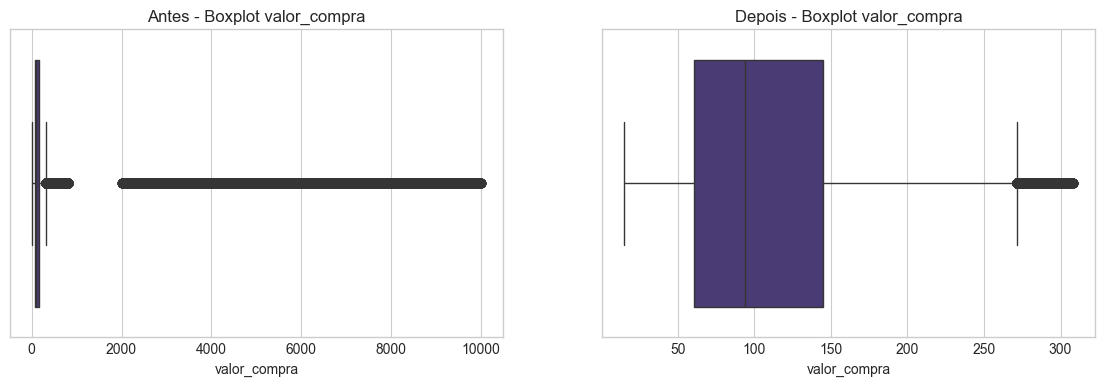

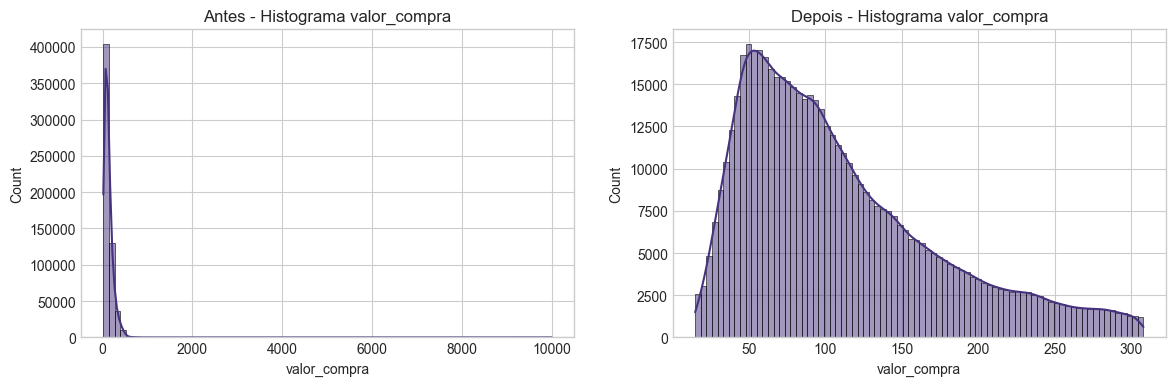

In [52]:
# Plots comparativos - antes/ depois para cada coluna
import math

def plot_before_after(col, df_before, df_after, bins=50):
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df_before[col])
    plt.title(f'Antes - Boxplot {col}')
    plt.subplot(1,2,2)
    sns.boxplot(x=df_after[col])
    plt.title(f'Depois - Boxplot {col}')
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(df_before[col].dropna(), bins=bins, kde=True)
    plt.title(f'Antes - Histograma {col}')
    plt.subplot(1,2,2)
    sns.histplot(df_after[col].dropna(), bins=bins, kde=True)
    plt.title(f'Depois - Histograma {col}')
    plt.show()

for c in cols_outlier:
    plot_before_after(c, df_clean_step1, df_limpo, bins=80)


o pq tirei os outliers da analise ( devido a uma estratégia mais personalizada e especifica)

In [53]:
# Análise do impacto da remoção de outliers nas métricas centrais

impacto_outliers = []

for c in cols_outlier:
    media_antes = df_clean_step1[c].mean()
    media_depois = df_limpo[c].mean()
    
    reducao_pct = ((media_antes - media_depois) / media_antes) * 100
    
    impacto_outliers.append({
        'variavel': c,
        'media_antes': media_antes,
        'media_depois': media_depois,
        'reducao_percentual (%)': reducao_pct
    })
    
    print(
        f"{c} -> média antes: {media_antes:.2f} | "
        f"média depois: {media_depois:.2f} | "
        f"redução: {reducao_pct:.2f}%"
    )

impacto_outliers_df = pd.DataFrame(impacto_outliers)
impacto_outliers_df


valor_compra -> média antes: 182.94 | média depois: 110.29 | redução: 39.71%


,variavel,media_antes,media_depois,reducao_percentual (%)
0,valor_compra,182.940042,110.29133,39.711761


### Impacto da Remoção de Outliers nas Métricas Centrais

A remoção dos outliers provocou uma redução significativa nas médias das variáveis analisadas, evidenciando a influência dos valores extremos sobre as métricas centrais da base.

No caso do **valor_compra**, o impacto foi ainda mais expressivo: a média passou de **R$ 183,94** para **R$ 110,29**, representando uma **redução de cerca de 39,71%**. Isso reforça que compras pontuais de alto valor exerciam forte influência sobre a média, sem necessariamente refletir o comportamento recorrente da maioria dos clientes.

Os gráficos comparativos (boxplots e histogramas) corroboram essa análise, mostrando distribuições mais concentradas e representativas após o tratamento. Esse ajuste contribui para maior estabilidade estatística e reduz o risco de distorção em modelos sensíveis à escala e à distância.



In [54]:
# Resumo detalhado do tratamento de dados

# Base original
linhas_original = df.shape[0]

# Após remoção de nulos
linhas_pos_nulos = df_clean_step1.shape[0]
removidos_nulos = linhas_original - linhas_pos_nulos
pct_nulos = (removidos_nulos / linhas_original) * 100

# Outliers (separados, não imputados)
linhas_outliers = df_outliers.shape[0]
pct_outliers = (linhas_outliers / linhas_original) * 100

# Base final limpa
linhas_final = df_limpo.shape[0]
removidos_total = linhas_original - linhas_final
pct_total = (removidos_total / linhas_original) * 100

print("Resumo do Tratamento de Dados")
print("-" * 45)

print(f"Linhas na base original:            {linhas_original:,}")

print("\nRemoção de valores nulos:")
print(f" - Linhas removidas por nulos:      {removidos_nulos:,}")
print(f" - Percentual removido (nulos):     {pct_nulos:.2f}%")

print("\nTratamento de outliers:")
print(f" - Linhas separadas como outliers:  {linhas_outliers:,}")
print(f" - Percentual da base (outliers):   {pct_outliers:.2f}%")

print("\nResultado final:")
print(f" - Linhas na base final limpa:      {linhas_final:,}")
print(f" - Redução total da base:           {removidos_total:,} ({pct_total:.2f}%)")


Resumo do Tratamento de Dados
---------------------------------------------
Linhas na base original:            600,000

Remoção de valores nulos:
 - Linhas removidas por nulos:      11,872
 - Percentual removido (nulos):     1.98%

Tratamento de outliers:
 - Linhas separadas como outliers:  35,878
 - Percentual da base (outliers):   5.98%

Resultado final:
 - Linhas na base final limpa:      552,250
 - Redução total da base:           47,750 (7.96%)


## Interpretação dos Resultados

Inicialmente, a base continha **600.000 registros**. A remoção de valores nulos nas variáveis críticas resultou na exclusão de **11.872 linhas**, o que corresponde a **1,98%** do total. Esse impacto reduzido indica que a presença de dados ausentes era limitada e que a exclusão desses registros não comprometeu a representatividade da base.

Na etapa seguinte, foram identificados e separados **35.878 registros classificados como outliers**, equivalentes a **5,98%** da base original. Esses registros foram tratados separadamente por representarem comportamentos extremos que poderiam distorcer as métricas centrais utilizadas na análise RFM, sem necessariamente indicar inconsistências nos dados.

Ao final do processo, a base limpa resultante passou a conter **552.250 registros**, representando uma **redução total de 7,96%** em relação ao volume inicial. Apesar da redução, a base final manteve mais de **92,04% dos dados originais**, garantindo robustez estatística e maior consistência para o cálculo dos indicadores de **Recência, Frequência e Valor Monetário**.


### 1.3 Exportar resultados
Vamos salvar `df_limpo` e `df_outliers` em arquivos `.txt` tabulados (`sep='\t'`).


In [55]:
# 1.3 - Exportar df_limpo e df_outliers em formato CSV
path_limpo = OUT_DIR / 'df_limpo.csv'
path_outliers = OUT_DIR / 'df_outliers.csv'

df_limpo.to_csv(path_limpo, index=False)
df_outliers.to_csv(path_outliers, index=False)

print(f"df_limpo salvo como: {path_limpo.name}")
print(f"df_outliers salvo como: {path_outliers.name}")


df_limpo salvo como: df_limpo.csv
df_outliers salvo como: df_outliers.csv


Os datasets resultantes foram exportados no formato CSV padrão, facilitando a reabertura no pandas e garantindo maior interoperabilidade com outras ferramentas de análise e visualização de dados.


### Jusitificativas


### Tratamento de Valores Nulos — Decisão Metodológica

A remoção de registros com valores nulos foi aplicada **exclusivamente às variáveis consideradas críticas para a análise**, a saber: `frequencia_compras`, `valor_compra` e `renda_mensal`.

Optou-se pela **remoção seletiva** em vez da imputação por três motivos principais:
1. A proporção de registros removidos foi reduzida (inferior a 3%), não comprometendo a representatividade estatística da base.
2. A imputação poderia introduzir **viés artificial** em variáveis diretamente relacionadas ao comportamento e ao valor do cliente.


Dessa forma, a abordagem adotada prioriza a **integridade dos padrões observados**, mantendo a confiabilidade das análises subsequentes.


### Detecção de Outliers — Escolha do Método IQR

A detecção de outliers neste estudo foi realizada utilizando o método do **Intervalo Interquartil (IQR)**, em detrimento do método Z-score, considerando as características estatísticas das variáveis analisadas.

As distribuições de **renda_mensal** e **valor_compra** apresentam **assimetria positiva** e caudas superiores alongadas, comportamento comum em dados de consumo e renda. Nesses cenários, métodos baseados em média e desvio padrão, como o Z-score, tendem a ser menos adequados, pois assumem implicitamente uma aproximação à normalidade dos dados.

De acordo com Yaro, Maly e Prazak (2023), o método **Z-score identifica outliers com base na distância em relação à média**, enquanto abordagens baseadas em estatísticas robustas buscam reduzir a sensibilidade a distribuições não normais e valores extremos. Já o método **IQR identifica observações fora dos limites definidos pelos quartis**, não dependendo da suposição de normalidade, o que o torna mais apropriado para distribuições assimétricas.

Dessa forma, a escolha do método IQR se justifica por:
- Não assumir normalidade dos dados
- Ser mais robusto a distribuições assimétricas
- Reduzir o risco de classificar valores plausíveis como extremos
- Ser amplamente utilizado em análises exploratórias de dados econômicos e comportamentais

Essa abordagem garante uma identificação de outliers mais coerente com o comportamento real da base, evitando remoções indevidas e preservando informações relevantes para a análise RFM.

**Referência**

YARO, Abdulmalik Shehu; MALY, Filip; PRAZAK, Pavel. *Outlier detection in time-series receive signal strength observation using Z-score method with Sn scale estimator for indoor localization*. Applied Sciences, Basel, v. 13, n. 6, p. 3900, 2023. DOI: 10.3390/app13063900. Disponível em: <https://www.mdpi.com/2076-3417/13/6/3900>. Acesso em: 2026.



## RESUMO
As etapas de tratamento de dados foram realizadas com o objetivo de garantir a
consistência das métricas utilizadas na análise RFM (Recency, Frequency e
Monetary). A remoção de valores nulos foi restrita às variáveis diretamente
envolvidas no cálculo dos indicadores, evitando a criação de padrões artificiais
por meio de imputação.

Da mesma forma, os valores extremos foram analisados separadamente, uma vez que
podem representar comportamentos legítimos, porém capazes de distorcer a
distribuição dos scores RFM. Essa abordagem permite preservar a representatividade
da maioria dos clientes sem descartar informações relevantes.
